### Parcial #2: Punto 2

Aplicar un modelo de regresión lineal de la forma:
$$y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_{12}X_{12} + e$$
Sobre las medidas socioeconomicas de ciudades de estados unidos con el fin de predecir el total de delitos graves.

In [132]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import shapiro, normaltest
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, het_goldfeldquandt
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

In [133]:
data = pd.read_excel('Datos/datosp2p2.xls', header=2, sheet_name='Demography')
data.drop(data.columns[0], axis=1, inplace=True)
data.head(n=2)

,Total Delitos Graves,Área (Millas^2),Num Habitantes,% Población entre 18 y 34,% Población mayor a 65,Num Profesionales Médicos,Num Camas Hospitalarias,% Adultos con Bachillerato,% Adultos con Pregrado,% Población con Ingresos Menores al Umbral de Pobreza,% Fuerza Laboral sin Empleo,Ingreso per Cápita,Total Ingresos Personales en (Millones USD)
0,688936,4060,8863164,32.1,9.7,23677,27700,70.0,22.3,11.6,8.0,20786,184230
1,436936,946,5105067,29.2,12.4,15153,21550,73.4,22.8,11.1,7.2,21729,110928


In [134]:
# Matriz de diseño

X = data.drop(columns=['Total Delitos Graves'])
X = sm.add_constant(X)
y = data['Total Delitos Graves']

In [135]:
model = sm.OLS(y, X).fit()
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     Total Delitos Graves   R-squared:                       0.843
Model:                              OLS   Adj. R-squared:                  0.839
Method:                   Least Squares   F-statistic:                     191.5
Date:                  Wed, 25 Feb 2026   Prob (F-statistic):          2.29e-163
Time:                          19:08:55   Log-Likelihood:                -5043.8
No. Observations:                   440   AIC:                         1.011e+04
Df Residuals:                       427   BIC:                         1.017e+04
Df Model:                            12                                         
Covariance Type:              nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

### Interpretaciónes

[Página guia](https://www.geeksforgeeks.org/machine-learning/interpreting-the-results-of-linear-regression-using-ols-summary/)

1. **$\R^2$**: La interpretación de r cuadrado nos indica que más del 80% del valor del **Total de Delitos Graves** es explicado por nuestros indicadores socieconomicos.

2. **F-statistic y |Prob F-statistic|**: El valor asociado al F-statistic nos dice que tan significante es el modelo, nuestro valor cercano a cero en |Prob F-statistic| refuerza la idea inicial que tuvimos al analizar R cuadrado, y es que nuestro modelo es efectivamente significativo.

### Cumplimiento de supuestos

$$e \sim^{iid} \mathcal{N}(0, \sigma^2)$$

**Debemos cumplir lo siguiente:**
- **Normalidad**: Los residuos deben distribuirse normalmente.
- **Homocedasticidad**: La varianza de los residuos debe ser constante para todos los valores de X.
- **Independencia**: Este supuesto de la regresión lineal es que los residuos son independientes.
- **Ausencia de multicolinealidad**: Las variables independientes no deben estar muy correlacionadas entre sí.

1. **Omnibus:** (Evalua la normalidad de los residuos) Nuestro valor es muy alto, por lo que no cumple el supuesto, lo que se refuerza con la la probabilidad de este estadistico que es menor a 0.05.

2. **Jarque-Bera:** (Otrar prueba de normalidad) Tampoco nos indica que cumplamos el supuesto.

3. **Kurtosis:** Su valor tan lejano a 3 nos sugiere que no hay normalidad en los datos.

4. **Durbin-Watson:** Valores cercanos a 2 sugieren que no hay relación entre residuos consecutivos.

5. **Cond. No:** Valores encima de 30 sugieren multicolinedalidad, y nuestro valor es extremadamente grande.

**Conclusión:** Tenemos que hacer algo, no se estan cumpliiendo los supuestos, excepto por el de independencia, por lo que necesitamos realizar transformaciones. la siguiente es nuestra principal fuente de información sobre que transformaciones realizar en los datos [Link](https://statologos.com/lineal-regression-assumptions/) y este particularmente útil con la libreria que estamos usando [Link](https://www.statsmodels.org/stable/diagnostic.html), además y como primera acción hay que hacer algo con el problema númerico que nos dice la warning 2.

Cook Umbral: 0.0091
Number of outliers: 20 of 440


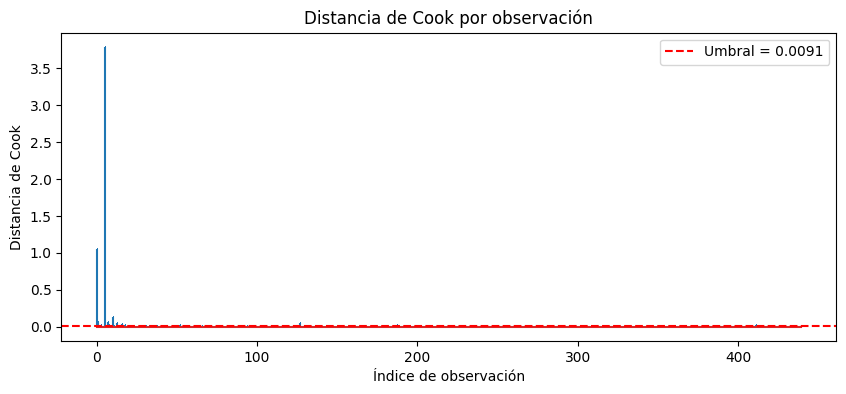

In [136]:
influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]

cooks_placeholder = 4 / len(y)
outliers = np.where(cooks_d > cooks_placeholder)[0]

print(f"Cook Umbral: {cooks_placeholder:.4f}")
print(f"Number of outliers: {len(outliers)} of {len(y)}")

plt.figure(figsize=(10, 4))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt=',')
plt.axhline(y=cooks_placeholder, color='red', linestyle='--', label=f'Umbral = {cooks_placeholder:.4f}')
plt.xlabel('Índice de observación')
plt.ylabel('Distancia de Cook')
plt.title('Distancia de Cook por observación')
plt.legend()
plt.show()

### Solucuión del segundo warning
Al hacer una evaluación de la multicolinealidad evaluando si el VIF > 10 elimine las variables con mayor de este, no obstante al eliminar todas el R cuadrado bajo a 0.16, por lo que perdimos casi toda la eficacia del modelo, por esto decidi dejar la cantidad de habitantes, ya que considero que las otras son formas diferentes en mayor o menor medida de representar este. Además toco buscar como escalar las variablesindependientes ya que este metodo es sensible a las escalas, por usar distancias.

In [137]:
vif_data = pd.DataFrame({
    'Variable': X.columns[1:],
    'VIF': [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

                                             Variable        VIF
          Total Ingresos Personales en (Millones USD) 119.349708
                                       Num Habitantes 119.062526
                            Num Profesionales Médicos  25.434414
                              Num Camas Hospitalarias  21.110385
                               % Adultos con Pregrado   6.513459
                                   Ingreso per Cápita   6.406511
                           % Adultos con Bachillerato   4.064895
% Población con Ingresos Menores al Umbral de Pobreza   3.851329
                            % Población entre 18 y 34   2.476448
                               % Población mayor a 65   1.842713
                          % Fuerza Laboral sin Empleo   1.838429
                                      Área (Millas^2)   1.290178


In [138]:
X_vif = X.drop(columns=['Total Ingresos Personales en (Millones USD)','Num Profesionales Médicos','Num Camas Hospitalarias'])

scaler = StandardScaler()
X_vif_scaled = X_vif.copy()
cols_to_scale = X_vif.columns.drop('const')
X_vif_scaled[cols_to_scale] = scaler.fit_transform(X_vif[cols_to_scale])

vif_data = pd.DataFrame({
    'Variable': X_vif_scaled.columns[1:],
    'VIF': [variance_inflation_factor(X_vif_scaled.values, i) for i in range(1, X_vif_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

                                             Variable      VIF
                               % Adultos con Pregrado 6.046369
                                   Ingreso per Cápita 4.427741
                           % Adultos con Bachillerato 4.025787
% Población con Ingresos Menores al Umbral de Pobreza 3.135408
                            % Población entre 18 y 34 2.371061
                          % Fuerza Laboral sin Empleo 1.747042
                               % Población mayor a 65 1.677702
                                       Num Habitantes 1.211305
                                      Área (Millas^2) 1.146388


In [139]:
model_vif = sm.OLS(y, X_vif_scaled).fit()
print(model_vif.summary())

                             OLS Regression Results                             
Dep. Variable:     Total Delitos Graves   R-squared:                       0.806
Model:                              OLS   Adj. R-squared:                  0.802
Method:                   Least Squares   F-statistic:                     198.2
Date:                  Wed, 25 Feb 2026   Prob (F-statistic):          5.98e-147
Time:                          19:08:55   Log-Likelihood:                -5091.1
No. Observations:                   440   AIC:                         1.020e+04
Df Residuals:                       430   BIC:                         1.024e+04
Df Model:                             9                                         
Covariance Type:              nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [140]:
model_iter = sm.OLS(y, X_vif_scaled).fit()
influence = OLSInfluence(model_iter)
cooks_d = influence.cooks_distance[0]

umbral_cook = 4 / len(y)
outliers = np.where(cooks_d > umbral_cook)[0]
print(f"Cook Umbral: {umbral_cook:.4f}")
print(f"Outliers number: {len(outliers)}")

X_clean = X_vif_scaled.drop(index=outliers).reset_index(drop=True)
y_clean = y.drop(index=outliers).reset_index(drop=True)

Cook Umbral: 0.0091
Outliers number: 10


In [141]:
model_clean = sm.OLS(y_clean, X_clean).fit()

stat_sw, pval_sw = shapiro(model_clean.resid)
stat_da, pval_da = normaltest(model_clean.resid)
print("Normality Tests")
print(f"Shapiro-Wilk:    stat={stat_sw:.4f}, p={pval_sw:.4f}")
print(f"D'Agostino:      stat={stat_da:.4f}, p={pval_da:.4f}")

lm_bp, lm_pval_bp, fval_bp, f_pval_bp = het_breuschpagan(model_clean.resid, model_clean.model.exog)

fitted_clean = model_clean.fittedvalues.values
exog_white_clean = np.column_stack([np.ones(len(fitted_clean)), fitted_clean, fitted_clean**2])
lm_w, lm_pval_w, fval_w, f_pval_w = het_white(model_clean.resid, exog_white_clean)

fval_gq, pval_gq, _ = het_goldfeldquandt(model_clean.resid, model_clean.model.exog)
print("Heteroscedasticity Tests")
print(f"Breusch-Pagan:   LM={lm_bp:.4f}, p={lm_pval_bp:.4f}")
print(f"White:           LM={lm_w:.4f}, p={lm_pval_w:.4f}")
print(f"Goldfeld-Quandt: F={fval_gq:.4f}, p={pval_gq:.4f}")

Normality Tests
Shapiro-Wilk:    stat=0.8977, p=0.0000
D'Agostino:      stat=75.9857, p=0.0000
Heteroscedasticity Tests
Breusch-Pagan:   LM=118.5353, p=0.0000
White:           LM=152.4241, p=0.0000
Goldfeld-Quandt: F=0.0535, p=1.0000


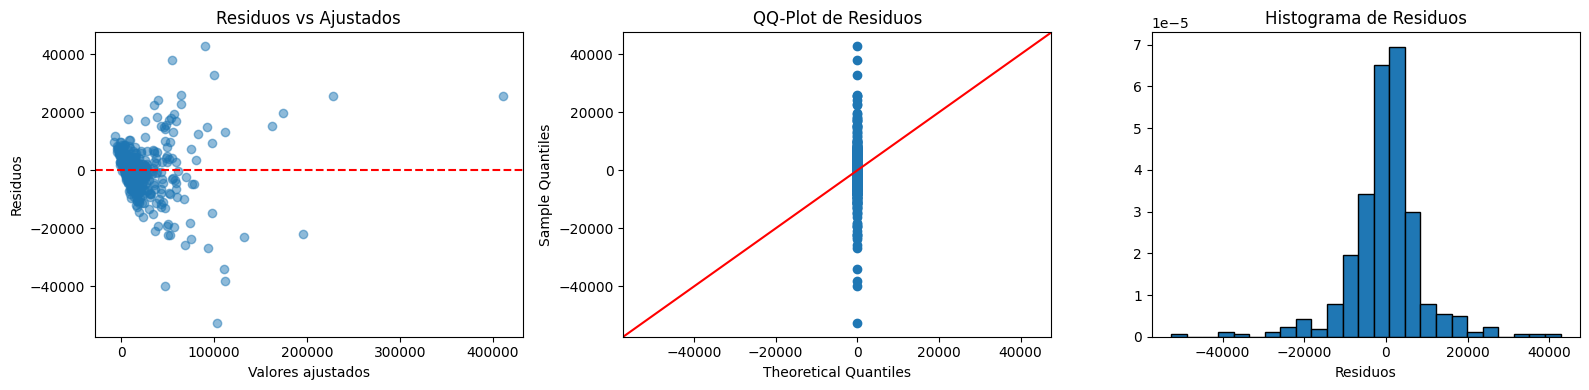

In [142]:
# https://www.youtube.com/watch?v=MuJvecsHkc8

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(model_clean.fittedvalues, model_clean.resid, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Ajustados')

sm.qqplot(model_clean.resid, line='45', ax=axes[1])
axes[1].set_title('QQ-Plot de Residuos')

axes[2].hist(model_clean.resid, bins=25, edgecolor='black', density=True)
axes[2].set_title('Histograma de Residuos')
axes[2].set_xlabel('Residuos')

plt.tight_layout()
plt.show()

In [143]:
X_log = X_vif.copy()
X_log['Num Habitantes'] = np.log(X_log['Num Habitantes'])
X_log.rename(columns={'Num Habitantes': 'ln(Num Habitantes)'}, inplace=True)

scaler2 = StandardScaler()
cols2 = X_log.columns.drop('const')
X_log[cols2] = scaler2.fit_transform(X_log[cols2])

y_log_all = np.log(y)
model_tmp = sm.OLS(y_log_all, X_log).fit()
cooks_tmp = OLSInfluence(model_tmp).cooks_distance[0]
outliers_log = np.where(cooks_tmp > 4/len(y))[0]

X_log_clean = X_log.drop(index=outliers_log).reset_index(drop=True)
y_log_clean = y_log_all.drop(index=outliers_log).reset_index(drop=True)

model_loglog = sm.OLS(y_log_clean, X_log_clean).fit()
print(model_loglog.summary())

                             OLS Regression Results                             
Dep. Variable:     Total Delitos Graves   R-squared:                       0.906
Model:                              OLS   Adj. R-squared:                  0.903
Method:                   Least Squares   F-statistic:                     428.3
Date:                  Wed, 25 Feb 2026   Prob (F-statistic):          7.39e-200
Time:                          19:08:56   Log-Likelihood:                -101.11
No. Observations:                   412   AIC:                             222.2
Df Residuals:                       402   BIC:                             262.4
Df Model:                             9                                         
Covariance Type:              nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

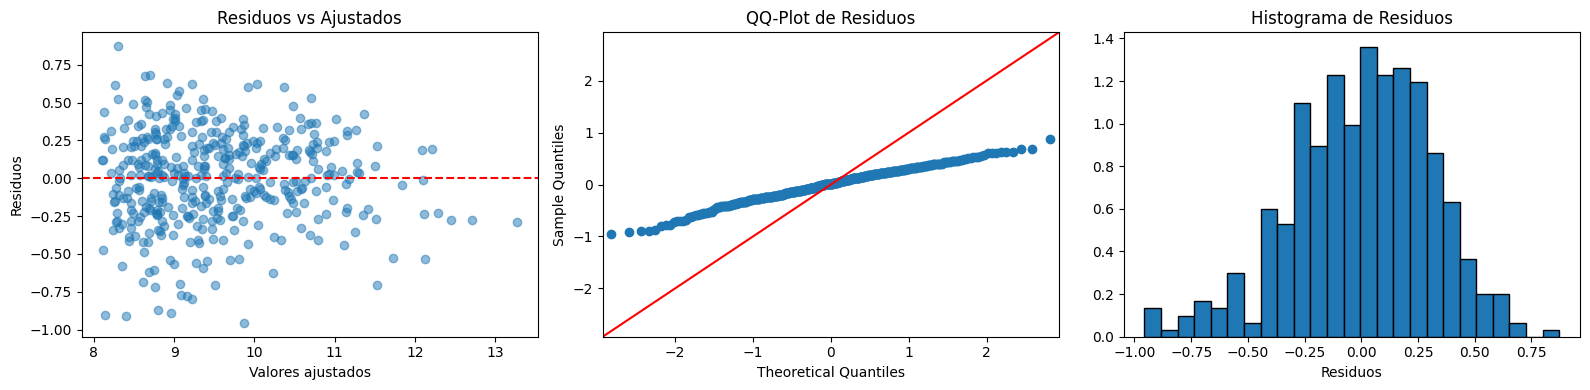

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(model_loglog.fittedvalues, model_loglog.resid, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Ajustados')

sm.qqplot(model_loglog.resid, line='45', ax=axes[1])
axes[1].set_title('QQ-Plot de Residuos')

axes[2].hist(model_loglog.resid, bins=25, edgecolor='black', density=True)
axes[2].set_title('Histograma de Residuos')
axes[2].set_xlabel('Residuos')

plt.tight_layout()
plt.show()

In [145]:
X_final = X_log_clean.drop(columns=['% Población mayor a 65', 'Ingreso per Cápita', '% Adultos con Bachillerato', 'Área (Millas^2)', '% Adultos con Pregrado'])
model_final = sm.OLS(y_log_clean, X_final).fit()
print(model_final.summary())

                             OLS Regression Results                             
Dep. Variable:     Total Delitos Graves   R-squared:                       0.905
Model:                              OLS   Adj. R-squared:                  0.904
Method:                   Least Squares   F-statistic:                     973.4
Date:                  Wed, 25 Feb 2026   Prob (F-statistic):          7.92e-207
Time:                          19:08:56   Log-Likelihood:                -101.55
No. Observations:                   412   AIC:                             213.1
Df Residuals:                       407   BIC:                             233.2
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

### Recta
$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \hat{\beta}_2 X_2 + \cdots + \hat{\beta}_{k} X_{k}$$

$$\ln(\hat{y}) = 9.5392 + 0.9601\ln(X_1) + 0.0521 X_2 + 0.2845 X_3 - 0.0782 X_4$$

- $\ln(\hat{y})$ = $\ln(\text{Total Delitos Graves})$
- $X_1$ = Num Habitantes
- $X_2$ = % Población entre 18 y 34 (estandarizada)
- $X_3$ = % Población con Ingresos Menores al Umbral de Pobreza (estandarizada)
- $X_4$ = % Fuerza Laboral sin Empleo (estandarizada)

### Interpretación de coeficientes

- **Intercepto** ($9.5392$): Valor de $\ln(\hat{y})$ cuando todo lo demás es 0. $e^{9.5392} \approx 13{,}952$ delitos, pero no tiene sentido práctico porque $\ln(X_1)=0$ implica 1 habitante.
- **$\ln(X_1)$** ($0.9601$): Relación log-log, si los habitantes aumentan 1%, los delitos aumentan ~0.96%.
- **$X_2$** ($0.0521$): Si sube 1 desviación estándar, los delitos suben ~$5.34\%$ $(e^{0.0521}-1)$.
- **$X_3$** ($0.2845$): Si sube 1 desviación estándar, los delitos suben ~$32.9\%$ $(e^{0.2845}-1)$.
- **$X_4$** ($-0.0782$): Si sube 1 desviación estándar, los delitos **bajan** ~$7.52\%$ $(1-e^{-0.0782})$.

> Solo $\ln(X_1)$ se interpreta como elasticidad directa (log-log) por la transformación que realizamos.

[Referencia](https://economipedia.com/definiciones/logaritmos-en-econometria.html)

In [146]:
y_pred_log = model_final.fittedvalues
y_pred = np.exp(y_pred_log)
y_real = np.exp(y_log_clean)

MSE = np.mean((y_real - y_pred)**2)
MSE_log = np.mean((y_log_clean - y_pred_log)**2)

print("Tight level:")
print(f"\tR²:              {model_final.rsquared:.8f}")
print(f"\tR² tight:        {model_final.rsquared_adj:.8f}")
print("MSE:")
print(f"\tMSE (log):       {MSE_log:.8f}")
print(f"\tMSE (original):  {MSE:.8f}")

Tight level:
	R²:              0.90536033
	R² tight:        0.90443021
MSE:
	MSE (log):       0.09585473
	MSE (original):  174462804.67756274


### Conclusión

Como conclusión final, podemos decir que obtuvimos un muy buen nivel de ajuste, incluso desde el comienzo el modelo era significativo. Encontramos problemas de multicolinealidad, causada por variables que eran muy dependientes entre sí, y de inestabilidad numérica (Cond. No. muy alto) causada por las diferencias de escala entre las variables, ya que este metodo al basarse en distancias es muy sensible a esto. Resolvimos la multicolinealidad eliminando 3 de las 4 variables altamente multicorelacionadas y la inestabilidad numérica mediante estandarización con StandardScaler.

Posteriormente, eliminamos outliers usando la distancia de Cook y aplicamos una transformación logarítmica tanto a la variable dependiente como a Num Habitantes (modelo log-log parcial), lo que mejoró drásticamente la normalidad y redujo la heterocedasticidad visible en los gráficos de residuos.

Finalmente, removimos las variables no significativas, quedándonos con 4 predictores, todos con $p < 0.05$. Aunque purebas como Jaquer Bera aún no apoyan la normalidad, los estadísticos descriptivos y el QQ-plot indican una distribución razonablemente normal.